# PatchCore Pipeline: Anomaly Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm
import sys
import cv2

# Patch for pandas 2.0+ compatibility with the pickled dataset
import pandas.core.indexes
sys.modules['pandas.indexes'] = pandas.core.indexes
try:
    import pandas.core.indexes.base
    sys.modules['pandas.indexes.base'] = pandas.core.indexes.base
except ImportError:
    pass


## 1. Data Loading and Preprocessing

In [2]:
# Load dataset
print("Loading LSWMD.pkl...")
with open('LSWMD.pkl', 'rb') as f:
    df = pickle.load(f, encoding='latin1')

# Clean failureType column
def extract_val(x):
    if type(x) == list or type(x).__name__ == 'ndarray':
        if len(x) > 0:
            if type(x[0]) == list or type(x[0]).__name__ == 'ndarray':
                if len(x[0]) > 0:
                    return x[0][0]
                return None
            return x[0]
        return None
    return x

df['failureType'] = df['failureType'].apply(extract_val)
df['trianTestLabel'] = df['trianTestLabel'].apply(extract_val)

print("Total elements:", len(df))
df.head(2)

Loading LSWMD.pkl...


/var/folders/m_/4r8l9_rn6jng5pdc6lth0yhr0000gn/T/ipykernel_734/3079131210.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  df = pickle.load(f, encoding='latin1')


Total elements: 811457


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,Training,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,Training,none


In [3]:
class WaferDataset(Dataset):
    def __init__(self, df, transform=None, img_size=(64, 64)):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.img_size = img_size
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        wafer = self.df.loc[idx, 'waferMap']
        
        # Resize nearest neighbor to preserve 0,1,2 classes
        wafer_resized = cv2.resize(wafer, self.img_size, interpolation=cv2.INTER_NEAREST)
        
        # Convert discrete classes to RGB channels (very simplified representation)
        # Background: 0, Normal: 1, Defect: 2
        rgb = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.float32)
        rgb[:, :, 0][wafer_resized == 1] = 1.0  # Normal parts in red channel
        rgb[:, :, 1][wafer_resized == 2] = 1.0  # Defect parts in green channel
        
        if self.transform:
            img_tensor = self.transform(rgb)
        else:
            img_tensor = torch.tensor(rgb).permute(2, 0, 1) # CxHxW
            
        label = self.df.loc[idx, 'failureType']
        is_anomaly = 0 if label == 'none' else 1
        return img_tensor, is_anomaly

# We want 'none' (normal) for training Patchcore. Any real defect is an anomaly.
from sklearn.model_selection import train_test_split

df = df.dropna(subset=['failureType'])
none_df = df[df['failureType'] == 'none']
defect_df = df[df['failureType'] != 'none']

train_none, test_none = train_test_split(none_df, test_size=0.05, random_state=42)
_, test_defects = train_test_split(defect_df, test_size=0.05, stratify=defect_df['failureType'], random_state=42)

df_train = train_none.reset_index(drop=True)
df_test = pd.concat([test_none, test_defects]).sample(frac=1, random_state=42).reset_index(drop=True)

train_ds = WaferDataset(df_train, img_size=(128, 128))
test_ds = WaferDataset(df_test, img_size=(128, 128))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
print(f"Train samples (normal): {len(train_ds)}, Test samples (mixed): {len(test_ds)}")

Train samples (normal): 140059, Test samples (mixed): 8648


## 2. Model Definition (ResNet Backbone)

In [4]:
class PatchCoreFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        # Use ResNet-18 as backbone for speed
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        
        # Extract features from layers 2 and 3 usually works well for PatchCore
        self.layer2 = nn.Sequential(*list(backbone.children())[:6])
        self.layer3 = list(backbone.children())[6]
        
        for param in self.parameters():
            param.requires_grad = False
            
        self.eval()

    def forward(self, x):
        features2 = self.layer2(x)
        features3 = self.layer3(features2)
        return features2, features3

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print("Using device:", device)
extractor = PatchCoreFeatureExtractor().to(device)

Using device: mps


## 3. Populate Memory Bank

In [ ]:
# Populate memory bank
memory_bank = []

print("Extracting features for memory bank...")
with torch.no_grad():
    for imgs, _ in tqdm(train_loader):
        imgs = imgs.to(device)
        f2, f3 = extractor(imgs)
        
        # Average pooling to reduce memory footprint
        f2_pooled = F.avg_pool2d(f2, 3, 1, 1)
        f3_pooled = F.avg_pool2d(f3, 3, 1, 1)
        
        # Interpolate f3 to match f2 size
        f3_resized = F.interpolate(f3_pooled, size=f2_pooled.shape[2:], mode='bilinear', align_corners=False)
        
        # Concatenate features
        features = torch.cat([f2_pooled, f3_resized], dim=1)
        
        # Flatten spatial dimensions
        features = features.reshape(features.size(0), features.size(1), -1).permute(0, 2, 1)
        features = features.reshape(-1, features.size(2))
        
        memory_bank.append(features.cpu())

memory_bank = torch.cat(memory_bank, dim=0)

# Optional: Coreset subsampling could be applied here
if len(memory_bank) > 10000:
    idx = torch.randperm(len(memory_bank))[:10000]
    memory_bank = memory_bank[idx]

print("Memory Bank shape:", memory_bank.shape)

Extracting features for memory bank...


  0%|          | 0/4377 [00:00<?, ?it/s]

## 4. Evaluation

Evaluating on test set...


  0%|          | 0/7 [00:00<?, ?it/s]

PatchCore Anomaly Detection AUROC: 0.8532


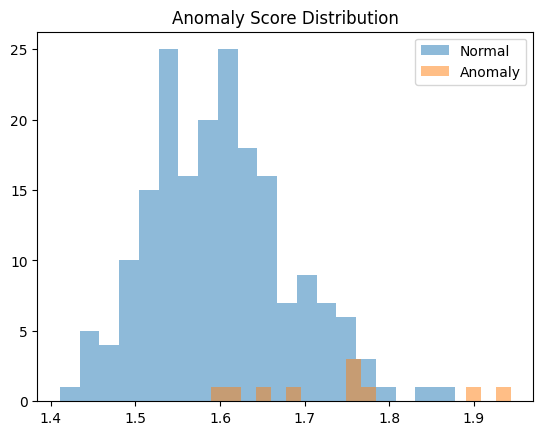

In [ ]:
print("Evaluating on test set...")
memory_bank = memory_bank.to(device)
all_scores = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader):
        imgs = imgs.to(device)
        f2, f3 = extractor(imgs)
        
        f2_pooled = F.avg_pool2d(f2, 3, 1, 1)
        f3_pooled = F.avg_pool2d(f3, 3, 1, 1)
        f3_resized = F.interpolate(f3_pooled, size=f2_pooled.shape[2:], mode='bilinear', align_corners=False)
        
        features = torch.cat([f2_pooled, f3_resized], dim=1)
        b, c, h, w = features.shape
        features = features.reshape(b, c, -1).permute(0, 2, 1)
        
        # Compute distances for each item in batch
        for i in range(b):
            patch_features = features[i]  # Shape: (h*w, c)
            
            # Compute distance to memory bank nearest neighbors
            dists = torch.cdist(patch_features, memory_bank)
            min_dists, _ = torch.min(dists, dim=1)
            
            # Image score is max of minimum patch distances
            img_score = torch.max(min_dists).item()
            all_scores.append(img_score)
            
        all_labels.extend(labels.numpy())

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

auc = roc_auc_score(all_labels, all_scores)
print(f"PatchCore Anomaly Detection AUROC: {auc:.4f}")

# Plot distributions
plt.figure()
plt.hist(all_scores[all_labels==0], bins=20, alpha=0.5, label='Normal')
plt.hist(all_scores[all_labels==1], bins=20, alpha=0.5, label='Anomaly')
plt.legend()
plt.title('Anomaly Score Distribution')
plt.show()